## Code for a one-dimensional lake model

Biogeochemical Modelling of Lakes, Sediments and Oceans.

Martin Schmid, BMSLO, FS 2026

This code implements a one-dimensional (vertically resolved) lake model for two state variables using the package FiPy.
In some cells, different options are given that can be activated by commenting/uncommenting the respective code.

Note: when changing parameters, make sure to re-run the entire code (specifically also the initial conditions).

In [2]:
# Import packages
from fipy import (CellVariable, Grid1D, TransientTerm, DiffusionTerm, 
    PowerLawConvectionTerm, FaceVariable)
from fipy.terms import ImplicitSourceTerm
import numpy as np
from scipy.stats import norm # function for normal distribution of inflows
from tqdm import tqdm # for tracking progress
import matplotlib.pyplot as plt

In [3]:
# Definition of Space and Time grids
Zmax = 20.0   # lake depth [m]
N = 200       # number of spatial nodes (grid centers)
dz = Zmax / N
mesh = Grid1D(nx=N, dx=dz)

tmax = 500.0  # days
M = 501
t = np.linspace(0.0, tmax, M)
dt = tmax / (M - 1)

In [4]:
# Definition of model parameters

# For easier readability of the code, make the mesh availabale as variable z
z = mesh.x

# Area as a function of depth
A_surf = 200000.0 # lake surface area
dAdz = -10000.0 # change of area with depth
A = A_surf + dAdz * z

# Diffusivity as a function of depth
z_mix = 10.0
Kz_top = 10.0  # m2/d
Kz_bottom = 0.02  # m2/d
Kz = Kz_top*(z < z_mix) + Kz_bottom*(z >= z_mix)

# normally distributed inflow calculated using scipy.stats.norm
# Note: when you define an inflow like this, but no corresponding 
# outflow, there will be an advective term at the surface, i.e.
# all variables including the advective term in the equation
# will move across the lake surface boundary.

Qin = 10000.0
z_mean = 10.0
z_range = 0.2
norma = norm(z_mean, z_range)
Q = Qin * (1.0 - norma.cdf(z))    # cumulative inflow below z
diffQ = Qin * norma.pdf(z)        # value of inflow at depth z

# inflow concentrations
C1_in = 15.0
C2_in = 45.0

# reaction rate
kr = 0.1

In [5]:
# Convert depth-dependendent model parameters to FiPy CellVariables available at grid center locations

Avar = CellVariable(mesh=mesh, value=A) # area
Kzvar = CellVariable(mesh=mesh, value=Kz) # diffusivity

diffCoeff = Avar * Kzvar # coefficient in diffusive term

# coefficient in advective (convective) term, minus sign because of flow direction
u = CellVariable(mesh=mesh, value=-Q)
convCoeff = u * [[1]] # needed because FiPy expects the coefficient for advection in vector format.

# inflows of C1 and C2 for source term
inflow1 = CellVariable(mesh=mesh, value=diffQ * C1_in) 
inflow2 = CellVariable(mesh=mesh, value=diffQ * C2_in)

In [6]:
# Definition of state variables and their initial conditions
C1 = CellVariable(mesh=mesh, name="C1", value=0.0, hasOld=True) # hasOld=True is needed to use updateOld below
C2 = CellVariable(mesh=mesh, name="C2", value=0.0, hasOld=True)
C2[:] = 0.5 * mesh.x  # depth-dependent initial condition for C2, overwirtes value defined in CellVariable above

In [7]:
# Define boundary conditions

# Note: the default for FiPy are no-flux boundary conditions
# if you want no flux, you do not need to specify boundary conditions
# if you want other boundary conditions, uncomment the respective code below


# Dirichlet conditions (constant concentrations)

C1_surf = 5.0
C1.constrain(C1_surf, mesh.facesLeft)
# C2_surf = 10.0
# C2.constrain(C2_surf, mesh.facesLeft)
# C1_bottom = 20.0
# C1.constrain(C1_bottom, mesh.facesRight)
# C2_bottom = 30.0
# C2.constrain(C2_bottom, mesh.facesRight)


# Neumann conditions (constant gradients)
# note, this defines the gradients. If you want to define the fluxes, 
# the gradients need to be defined such that you get the desired fluxes when
# multiplying them with the diffusivity at the top or bottom, respectively
# note: because z is positive downwards, a positive gradient results in a 
# sink at the lake surface but a source at the lake bottom.

# C1_grad_surf = 0.0
# C1.faceGrad.constrain(C1_grad_surf, mesh.facesLeft)
C2_grad_surf = 0.0
C2.faceGrad.constrain(C2_grad_surf, mesh.facesLeft)
C1_grad_bottom = 0.0
C1.faceGrad.constrain(C1_grad_bottom, mesh.facesRight)
C2_grad_bottom = 0.0
C2.faceGrad.constrain(C2_grad_bottom, mesh.facesRight)



In [8]:
# Define model equations for C1 and C2
# Note the different definitions of the sink term in the equation of C1 
# and the source term in the equation of C2 (which depends on the value of C1).

C1_equation = (
    TransientTerm(coeff=Avar, var=C1)
    == DiffusionTerm(coeff=diffCoeff, var=C1)
     - PowerLawConvectionTerm(coeff=convCoeff, var=C1)
     + ImplicitSourceTerm(coeff= -kr * Avar, var=C1)
     + inflow1
)

C2_equation = (
    TransientTerm(coeff=Avar, var=C2)
    == DiffusionTerm(coeff=diffCoeff, var=C2)
     - PowerLawConvectionTerm(coeff=convCoeff, var=C2)
     + (kr * Avar * C1)
     + inflow2
)

# Example for gas exchange. This needs to be implemented with an Implicit
# source term in the boundary cell and an explicit sink term.

# C1_eq = 10.0 # equilibrium concentration at lake surface
# v_gas_1 = 0.1 # gas exchange velocity (m/d)
# A_surf = float(Avar.value[0])     # [m^2] top cell cross-sectional area

# F1_gas_in = np.zeros(N)
# F1_gas_out = np.zeros(N)
# F1_gas_in[0] = C1_eq*v_gas_1*A_surf/dz
# F1_gas_out[0] = -v_gas_1*A_surf/dz

# # Convert to FiPy CellVariables
# F1_gas_in_var = CellVariable(mesh=mesh, value=F1_gas_in)
# F1_gas_out_var = CellVariable(mesh=mesh, value=F1_gas_out)

# C1_equation = (
#     TransientTerm(coeff=Avar, var=C1)
#     == DiffusionTerm(coeff=diffCoeff, var=C1)
#      - PowerLawConvectionTerm(coeff=convCoeff, var=C1)
#      + ImplicitSourceTerm(coeff = (F1_gas_out_var -kr * Avar), var=C1)
#      + inflow1
#      + F1_gas_in_var
# )

In [9]:
# Solve the equation

# Pre-allocate memory for solution
sol_C1 = np.zeros((N, M))
sol_C2 = np.zeros((N, M))
sol_C1[:, 0] = C1.value
sol_C2[:, 0] = C2.value

# solving differential equations
for n in tqdm(range(1,M), desc="Lake model simulation"):
    C1.updateOld()
    C2.updateOld()
    C1_equation.solve(var=C1, dt=dt)
    C2_equation.solve(var=C2, dt=dt)
    sol_C1[:, n] = C1.value
    sol_C2[:, n] = C2.value


Lake model simulation: 100%|█████████████████████████████████████████████████████████| 500/500 [00:08<00:00, 59.68it/s]


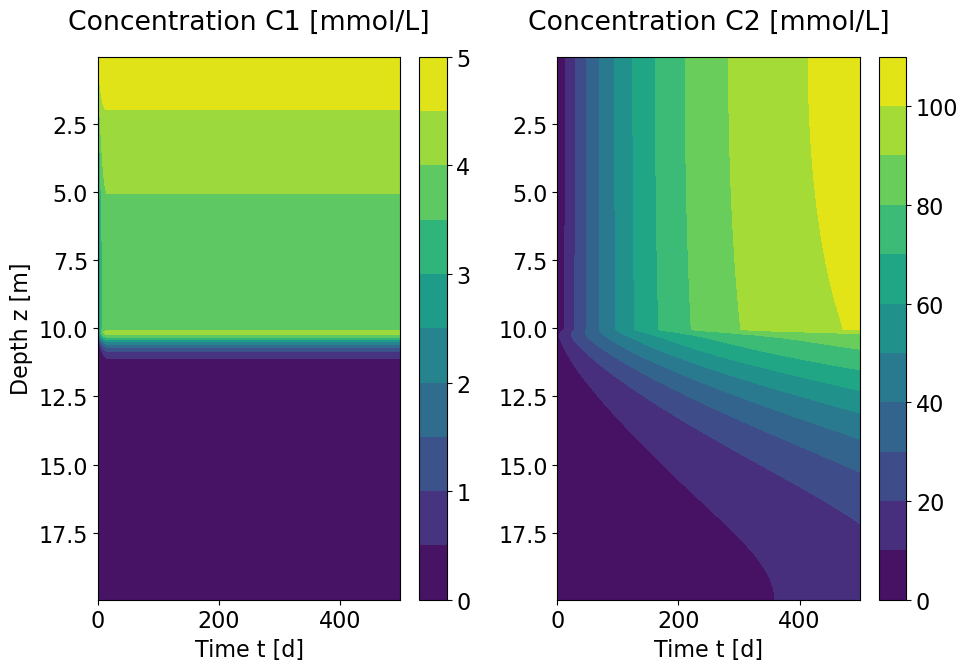

In [10]:
# ---------------------Plots-------------------------------

# plot temporal development
# Figsize defines the size of the plot
plt.figure(figsize=(10, 7))
plt.rcParams.update({'font.size': 16})

# contour plot C1
ax = plt.subplot(1, 2, 1)
plt.contourf(t, z, sol_C1, 10)
plt.colorbar()
plt.title("Concentration C1 [mmol/L]", pad=20)
ax.invert_yaxis()
plt.xlabel('Time t [d]')
plt.ylabel('Depth z [m]')

# contour plot C2
ax = plt.subplot(1, 2, 2)
plt.contourf(t, z, sol_C2, 10)
plt.colorbar()
plt.title("Concentration C2 [mmol/L]", pad=20)
ax.invert_yaxis()
plt.xlabel('Time t [d]')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Depth z [m]')

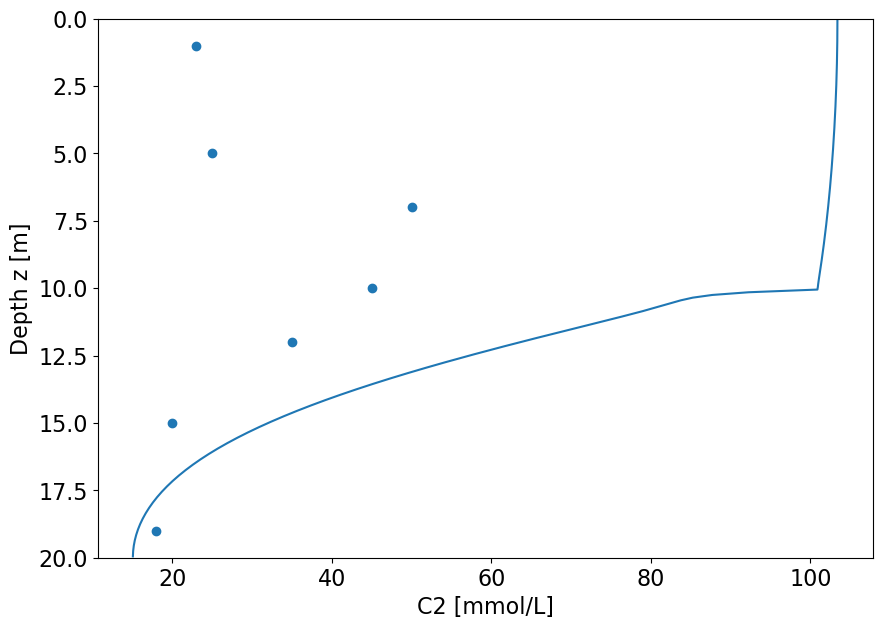

In [11]:
# plot "observed" data of C2 at time 500 d vs the simulation results.
plt.figure(figsize=(10, 7))
depths=[1,5,7,10,12,15,19]
C2_obs=[23,25,50,45,35,20,18]
plt.scatter (C2_obs, depths)
plt.plot(sol_C2[:, -1],z)
plt.ylim((0,20))
ax = plt.gca()
ax.invert_yaxis()
plt.xlabel('C2 [mmol/L]')
plt.ylabel('Depth z [m]')